# 📚 AI Research Paper Intelligence System — CBSOT Summer Internship 2026
## Notebook 1: Dataset Loading, EDA & FAISS Index Building

**Dataset:** CShorten/ML-ArXiv-Papers (HuggingFace) — 50,000 ArXiv ML Papers  
**Goal:** Load dataset, explore it, build FAISS semantic search index  

---

## 1. Install Dependencies

In [1]:
!pip install datasets sentence-transformers faiss-cpu transformers keybert torch -q
!pip install networkx pyvis reportlab spacy -q
!python -m spacy download en_core_web_sm -q
print('All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed!


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss

os.makedirs('outputs/faiss_index', exist_ok=True)
os.makedirs('outputs/data', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Libraries imported!')

Libraries imported!


## 3. Load Dataset

In [3]:
print('Loading CShorten/ML-ArXiv-Papers dataset...')
print('(This may take 2-3 minutes on first run)')

dataset = load_dataset('CShorten/ML-ArXiv-Papers', split='train')
df = pd.DataFrame(dataset)

print(f'\n✅ Dataset loaded!')
print(f'   Total papers : {len(df):,}')
print(f'   Columns      : {list(df.columns)}')
df.head(3)

Loading CShorten/ML-ArXiv-Papers dataset...
(This may take 2-3 minutes on first run)


README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]


✅ Dataset loaded!
   Total papers : 117,592
   Columns      : ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract']


,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...


In [4]:
# Keep 50k papers
df = df.sample(50000, random_state=42).reset_index(drop=True)

# Clean
df = df.dropna(subset=['title', 'abstract'])
df['title']    = df['title'].str.strip()
df['abstract'] = df['abstract'].str.strip()
df['text']     = df['title'] + ' ' + df['abstract']  # combined for embedding

print(f'Working with {len(df):,} papers')
print(f'Sample title: {df["title"].iloc[0]}')

Working with 50,000 papers
Sample title: SVD Perspectives for Augmenting DeepONet Flexibility and
  Interpretability


## 4. EDA — Exploratory Data Analysis

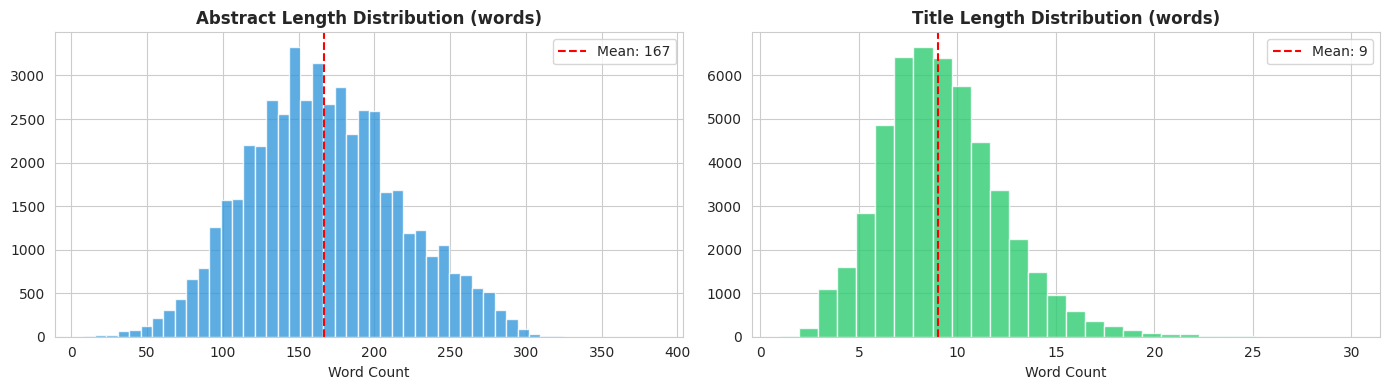

Abstract — Mean: 167 words | Max: 385 | Min: 8
Title    — Mean: 9 words | Max: 30 | Min: 1


In [5]:
# Abstract length distribution
df['abstract_len'] = df['abstract'].str.split().str.len()
df['title_len']    = df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['abstract_len'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Abstract Length Distribution (words)', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].axvline(df['abstract_len'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["abstract_len"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['title_len'], bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('Title Length Distribution (words)', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].axvline(df['title_len'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["title_len"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/01_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Abstract — Mean: {df["abstract_len"].mean():.0f} words | Max: {df["abstract_len"].max()} | Min: {df["abstract_len"].min()}')
print(f'Title    — Mean: {df["title_len"].mean():.0f} words | Max: {df["title_len"].max()} | Min: {df["title_len"].min()}')

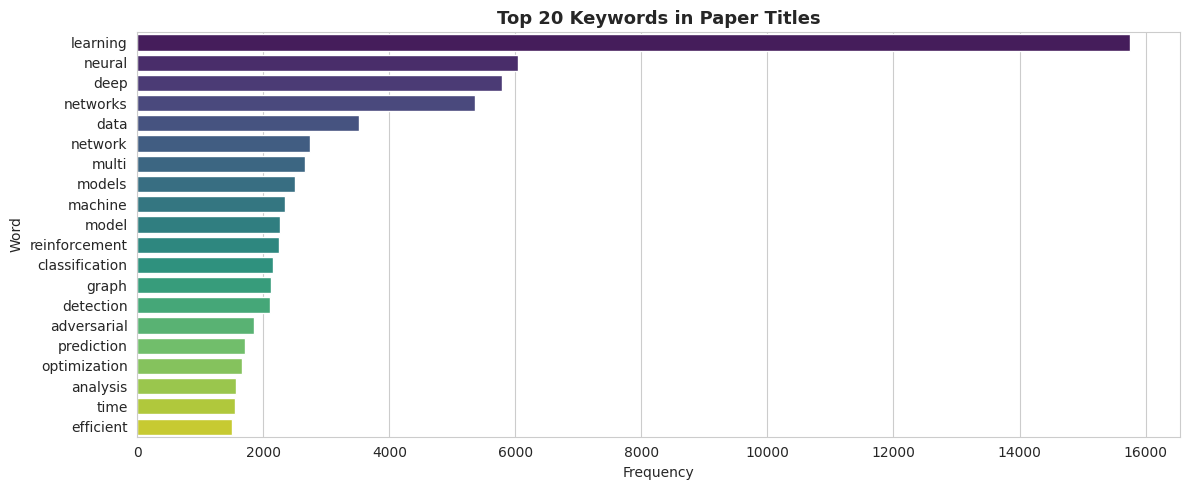

In [6]:
# Top keywords in titles
from collections import Counter
import re

stopwords = {'the','a','an','of','for','in','on','with','and','to','using','via',
             'based','from','by','is','are','that','this','we','our','paper','approach'}

all_words = []
for title in df['title']:
    words = re.findall(r'\b[a-zA-Z]{4,}\b', title.lower())
    all_words.extend([w for w in words if w not in stopwords])

top_words = Counter(all_words).most_common(20)
words_df = pd.DataFrame(top_words, columns=['Word','Count'])

plt.figure(figsize=(12, 5))
sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')
plt.title('Top 20 Keywords in Paper Titles', fontweight='bold', fontsize=13)
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('outputs/02_top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Build Sentence Embeddings

In [7]:
print('Loading sentence-transformers model...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded! Embedding dimension: {model.get_sentence_embedding_dimension()}')

Loading sentence-transformers model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded! Embedding dimension: 384


In [ ]:
print('Encoding 50,000 papers... (5-10 min on Colab GPU)')
print('Tip: Runtime > Change runtime type > T4 GPU for faster encoding')

embeddings = model.encode(
    df['text'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'\n✅ Embeddings shape: {embeddings.shape}')

Encoding 50,000 papers... (5-10 min on Colab GPU)
Tip: Runtime > Change runtime type > T4 GPU for faster encoding


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

## 6. Build FAISS Index

In [ ]:
# Normalize for cosine similarity
faiss.normalize_L2(embeddings)

# Build index
dimension = embeddings.shape[1]  # 384
index = faiss.IndexFlatIP(dimension)  # Inner Product = cosine after normalization
index.add(embeddings)

print(f'✅ FAISS index built!')
print(f'   Total vectors indexed: {index.ntotal:,}')
print(f'   Embedding dimension  : {dimension}')

In [ ]:
# Quick test
test_query = 'transformer attention mechanism natural language processing'
q_emb = model.encode([test_query], convert_to_numpy=True)
faiss.normalize_L2(q_emb)
scores, indices = index.search(q_emb, 5)

print(f'Test query: "{test_query}"')
print('Top 5 results:')
for i, (idx, score) in enumerate(zip(indices[0], scores[0])):
    print(f'  {i+1}. [{score:.4f}] {df["title"].iloc[idx]}')

## 7. Save Everything

In [ ]:
# Save FAISS index
faiss.write_index(index, 'outputs/faiss_index/papers.index')

# Save dataframe
df[['title','abstract','text']].to_pickle('outputs/data/papers_df.pkl')

# Save embeddings
np.save('outputs/data/embeddings.npy', embeddings)

print('✅ All files saved!')
print('   outputs/faiss_index/papers.index')
print('   outputs/data/papers_df.pkl')
print('   outputs/data/embeddings.npy')
print('\n➡️  Next: Run Notebook 2!')